**Comparison**

In [27]:
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
from pathlib import Path

# ============================================================
# SETTINGS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre")

SCENARIO_NAME = "weekend_evening"
# options:
# "weekday_morning", "weekday_evening",
# "weekend_morning", "weekend_evening"

REAL_FILE = BASE_DIR / rf"detector_data_aktuell\representative_day_routesampler_base_warmup15\{SCENARIO_NAME}_detector_15min_counts_analysis_only.csv"
SIM_E1_FILE = BASE_DIR / r"digital_twin\simulation\Corridor_e1_output.xml"

OUT_DIR = BASE_DIR / r"digital_twin\validation_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# warm-up ignored -> compare only 900-4500
SIM_BEGINS = [900, 1800, 2700, 3600]
SIM_ENDS = [1800, 2700, 3600, 4500]

# ============================================================
# SUMO DETECTOR ID -> (intersection, detector_id)
# ============================================================

SUMO_ID_MAP = {
    # LSA10
    "LSA10_E_id3":   ("LD-LSA10", 3),
    "LSA10_E_id4":   ("LD-LSA10", 4),
    "LSA10_NE_id29": ("LD-LSA10", 29),
    "LSA10_NW_id2":  ("LD-LSA10", 2),
    "LSA10_NW_id26": ("LD-LSA10", 26),
    "LSA10_NW_id27": ("LD-LSA10", 27),
    "LSA10_S_id31":  ("LD-LSA10", 31),
    "LSA10_W_id1":   ("LD-LSA10", 1),

    # LSA16
    "LSA16_E_id10":    ("LD-LSA16", 10),
    "LSA16_E_id11":    ("LD-LSA16", 11),
    "LSA16_E_id14":    ("LD-LSA16", 14),
    "LSA16_Eout_id13": ("LD-LSA16", 13),
    "LSA16_N_id6":     ("LD-LSA16", 6),
    "LSA16_N_id7":     ("LD-LSA16", 7),
    "LSA16_S_id1":     ("LD-LSA16", 1),
    "LSA16_S_id2":     ("LD-LSA16", 2),
    "LSA16_S_id33":    ("LD-LSA16", 33),
    "LSA16_W_id3":     ("LD-LSA16", 3),
    "LSA16_W_id4":     ("LD-LSA16", 4),
    "LSA16_W_id5":     ("LD-LSA16", 5),
    "LSA16_Wout_id15": ("LD-LSA16", 15),

    # LSA1
    "LSA1_E_id13": ("LD-LSA1", 13),
    "LSA1_E_id14": ("LD-LSA1", 14),
    "LSA1_E_id23": ("LD-LSA1", 23),
    "LSA1_E_id24": ("LD-LSA1", 24),
    "LSA1_E_id25": ("LD-LSA1", 25),
    "LSA1_E_id26": ("LD-LSA1", 26),
    "LSA1_E_id27": ("LD-LSA1", 27),
    "LSA1_N_id28": ("LD-LSA1", 28),
    "LSA1_N_id30": ("LD-LSA1", 30),
    "LSA1_N_id39": ("LD-LSA1", 39),
    "LSA1_N_id40": ("LD-LSA1", 40),
    "LSA1_S_id11": ("LD-LSA1", 11),
    "LSA1_S_id12": ("LD-LSA1", 12),
    "LSA1_W_id10": ("LD-LSA1", 10),
    "LSA1_W_id7":  ("LD-LSA1", 7),
    "LSA1_W_id8":  ("LD-LSA1", 8),
    "LSA1_W_id9":  ("LD-LSA1", 9),

    # LSA9
    "LSA9_E_id9":  ("LD-LSA9", 9),
    "LSA9_S_id10": ("LD-LSA9", 10),
    "LSA9_WE_id4": ("LD-LSA9", 4),
    "LSA9_WE_id5": ("LD-LSA9", 5),
    "LSA9_WE_id6": ("LD-LSA9", 6),
    "LSA9_WE_id7": ("LD-LSA9", 7),
    "LSA9_W_id1":  ("LD-LSA9", 1),
    "LSA9_W_id2":  ("LD-LSA9", 2),
}

# ============================================================
# VALIDATION DETECTORS
# ============================================================

VALIDATION_KEEP = {
    # LSA16
    ("LD-LSA16", 1), ("LD-LSA16", 2), ("LD-LSA16", 3), ("LD-LSA16", 4),
    ("LD-LSA16", 6), ("LD-LSA16", 7), ("LD-LSA16", 10), ("LD-LSA16", 11),
    ("LD-LSA16", 13), ("LD-LSA16", 15), ("LD-LSA16", 33),

    # LSA10
    ("LD-LSA10", 2), ("LD-LSA10", 3), ("LD-LSA10", 4), ("LD-LSA10", 1),
    ("LD-LSA10", 26), ("LD-LSA10", 27), ("LD-LSA10", 29), ("LD-LSA10", 31),

    # LSA1
    ("LD-LSA1", 7), ("LD-LSA1", 9), ("LD-LSA1", 13), ("LD-LSA1", 14),
    ("LD-LSA1", 23), ("LD-LSA1", 24), ("LD-LSA1", 26), ("LD-LSA1", 27),
    ("LD-LSA1", 28), ("LD-LSA1", 30), ("LD-LSA1", 40),

    # LSA9
    ("LD-LSA9", 1), ("LD-LSA9", 2), ("LD-LSA9", 4), ("LD-LSA9", 5),
    ("LD-LSA9", 6), ("LD-LSA9", 7), ("LD-LSA9", 9), ("LD-LSA9", 10),
}

EXCLUDE_VALIDATION = {
    ("LD-LSA1", 11),
    ("LD-LSA1", 12),
    ("LD-LSA1", 25),
    # add more here if needed
    # ("LD-LSA16", 5),
    # ("LD-LSA16", 14),
    # ("LD-LSA10", 1),
}

# ============================================================
# LSA16 APPROACH GROUPS
# ============================================================

LSA16_APPROACH_GROUPS = {
    "west_approach": [3, 4],
    "south_approach": [1, 2, 33],
    "east_approach": [10, 11],
    "north_approach": [6, 7],
    "exits": [13, 15],
}

LSA16_DETECTOR_LABELS = {
    1: "south_id1",
    2: "south_id2",
    3: "west_id3",
    4: "west_id4",
    6: "north_id6",
    7: "north_id7",
    10: "east_id10",
    11: "east_id11",
    13: "east_out_id13",
    15: "west_out_id15",
    33: "south_id33",
}

# ============================================================
# METRIC
# ============================================================

def geh(sim, obs):
    sim = np.asarray(sim, dtype=float)
    obs = np.asarray(obs, dtype=float)
    denom = sim + obs
    out = np.zeros_like(denom, dtype=float)
    mask = denom > 0
    out[mask] = np.sqrt(2.0 * (sim[mask] - obs[mask]) ** 2 / denom[mask])
    return out

# ============================================================
# READ REAL 15-MIN DATA
# ============================================================

real_df = pd.read_csv(REAL_FILE)

real_df["detector_id"] = pd.to_numeric(real_df["detector_id"], errors="coerce").astype("Int64")
real_df["count"] = pd.to_numeric(real_df["count"], errors="coerce").fillna(0)
real_df["begin_s"] = pd.to_numeric(real_df["begin_s"], errors="coerce")
real_df["end_s"] = pd.to_numeric(real_df["end_s"], errors="coerce")
real_df["key"] = list(zip(real_df["intersection"], real_df["detector_id"]))

real_df = real_df[
    real_df["key"].isin(VALIDATION_KEEP) &
    (~real_df["key"].isin(EXCLUDE_VALIDATION))
].copy()

real_df["bin_length_s"] = real_df["end_s"] - real_df["begin_s"]
real_df = real_df[real_df["bin_length_s"] == 900].copy()

real_bins = (
    real_df[["begin_s", "end_s"]]
    .drop_duplicates()
    .sort_values(["begin_s", "end_s"])
    .reset_index(drop=True)
)

if len(real_bins) != 4:
    raise ValueError(f"Expected exactly 4 real 15-min bins, found {len(real_bins)}.\n{real_bins}")

real_bins["real_bin_idx"] = range(4)
real_bins["bin_label"] = ["00-15", "15-30", "30-45", "45-60"]

real_agg = (
    real_df.groupby(
        ["intersection", "detector_id", "begin_s", "end_s"],
        as_index=False
    )["count"]
    .sum()
    .rename(columns={"count": "count_real"})
)

real_agg = real_agg.merge(
    real_bins,
    on=["begin_s", "end_s"],
    how="left"
)

real_agg["bin_idx"] = real_agg["real_bin_idx"]

print("\nREAL BINS USED:")
print(real_bins[["begin_s", "end_s", "bin_label"]].to_string(index=False))

# ============================================================
# READ SIM E1 OUTPUT
# ============================================================

tree = ET.parse(SIM_E1_FILE)
root = tree.getroot()

sim_rows = []
for interval in root.findall("interval"):
    sumo_id = interval.attrib.get("id")
    begin = int(float(interval.attrib.get("begin", 0)))
    end = int(float(interval.attrib.get("end", 0)))
    nVehEntered = float(interval.attrib.get("nVehEntered", 0))

    if sumo_id not in SUMO_ID_MAP:
        continue

    intersection, detector_id = SUMO_ID_MAP[sumo_id]
    key = (intersection, detector_id)

    if key not in VALIDATION_KEEP or key in EXCLUDE_VALIDATION:
        continue

    if begin not in SIM_BEGINS or end not in SIM_ENDS:
        continue

    sim_rows.append({
        "intersection": intersection,
        "detector_id": detector_id,
        "bin_idx": SIM_BEGINS.index(begin),
        "sim_begin_s": begin,
        "sim_end_s": end,
        "count_sim": nVehEntered
    })

sim_df = pd.DataFrame(sim_rows)

if sim_df.empty:
    raise ValueError("Simulation E1 output produced no matching rows.")

sim_agg = (
    sim_df.groupby(
        ["intersection", "detector_id", "bin_idx", "sim_begin_s", "sim_end_s"],
        as_index=False
    )["count_sim"]
    .sum()
)

# ============================================================
# BUILD FULL GRID
# ============================================================

detector_keys = sorted(list(VALIDATION_KEEP - EXCLUDE_VALIDATION))

grid_rows = []
for inter, det in detector_keys:
    for i, (sb, se) in enumerate(zip(SIM_BEGINS, SIM_ENDS)):
        grid_rows.append({
            "intersection": inter,
            "detector_id": det,
            "bin_idx": i,
            "sim_begin_s": sb,
            "sim_end_s": se
        })

grid_df = pd.DataFrame(grid_rows)

real_for_merge = real_agg[[
    "intersection", "detector_id", "bin_idx",
    "begin_s", "end_s", "bin_label", "count_real"
]]

cmp_df = (
    grid_df
    .merge(real_for_merge, on=["intersection", "detector_id", "bin_idx"], how="left")
    .merge(sim_agg, on=["intersection", "detector_id", "bin_idx", "sim_begin_s", "sim_end_s"], how="left")
)

cmp_df = cmp_df.merge(
    real_bins[["real_bin_idx", "begin_s", "end_s", "bin_label"]].rename(columns={"real_bin_idx": "bin_idx"}),
    on="bin_idx",
    how="left",
    suffixes=("", "_fallback")
)

cmp_df["begin_s"] = cmp_df["begin_s"].fillna(cmp_df["begin_s_fallback"])
cmp_df["end_s"] = cmp_df["end_s"].fillna(cmp_df["end_s_fallback"])
cmp_df["bin_label"] = cmp_df["bin_label"].fillna(cmp_df["bin_label_fallback"])

cmp_df = cmp_df.drop(columns=["begin_s_fallback", "end_s_fallback", "bin_label_fallback"])

cmp_df["count_real"] = cmp_df["count_real"].fillna(0)
cmp_df["count_sim"] = cmp_df["count_sim"].fillna(0)

cmp_df["diff_sim_minus_real"] = cmp_df["count_sim"] - cmp_df["count_real"]
cmp_df["GEH"] = geh(cmp_df["count_sim"], cmp_df["count_real"])

cmp_df = cmp_df.sort_values(["intersection", "detector_id", "bin_idx"]).copy()

# ============================================================
# DETECTOR TOTALS
# ============================================================

detector_totals = (
    cmp_df.groupby(["intersection", "detector_id"], as_index=False)
    .agg(
        total_real=("count_real", "sum"),
        total_sim=("count_sim", "sum"),
        diff_sim_minus_real=("diff_sim_minus_real", "sum"),
        mean_GEH=("GEH", "mean"),
        max_GEH=("GEH", "max"),
        GEH_lt_5_share_percent=("GEH", lambda s: (s < 5).mean() * 100),
        n_bins=("bin_idx", "count")
    )
    .sort_values(["intersection", "detector_id"])
)

# ============================================================
# INTERSECTION SUMMARY
# ============================================================

intersection_summary = (
    cmp_df.groupby("intersection", as_index=False)
    .agg(
        total_real=("count_real", "sum"),
        total_sim=("count_sim", "sum"),
        diff_sim_minus_real=("diff_sim_minus_real", "sum"),
        mean_GEH=("GEH", "mean"),
        max_GEH=("GEH", "max"),
        GEH_lt_5_share_percent=("GEH", lambda s: (s < 5).mean() * 100),
        n_rows=("bin_idx", "count")
    )
    .sort_values("intersection")
)

# ============================================================
# OVERALL SUMMARY
# ============================================================

overall_summary = pd.DataFrame([{
    "scenario": SCENARIO_NAME,
    "total_real": cmp_df["count_real"].sum(),
    "total_sim": cmp_df["count_sim"].sum(),
    "diff_sim_minus_real": cmp_df["diff_sim_minus_real"].sum(),
    "mean_GEH": cmp_df["GEH"].mean(),
    "max_GEH": cmp_df["GEH"].max(),
    "GEH_lt_5_share_percent": (cmp_df["GEH"] < 5).mean() * 100
}])

# ============================================================
# SAVE MAIN OUTPUTS
# ============================================================

cmp_out = OUT_DIR / f"{SCENARIO_NAME}_comparison_15min_counts_TRUE_warmup15.csv"
det_out = OUT_DIR / f"{SCENARIO_NAME}_detector_totals_counts_TRUE_warmup15.csv"
int_out = OUT_DIR / f"{SCENARIO_NAME}_intersection_summary_counts_TRUE_warmup15.csv"
ov_out = OUT_DIR / f"{SCENARIO_NAME}_overall_summary_counts_TRUE_warmup15.csv"

cmp_df.to_csv(cmp_out, index=False, encoding="utf-8-sig")
detector_totals.to_csv(det_out, index=False, encoding="utf-8-sig")
intersection_summary.to_csv(int_out, index=False, encoding="utf-8-sig")
overall_summary.to_csv(ov_out, index=False, encoding="utf-8-sig")

# ============================================================
# LSA16 APPROACH-WISE TABLES
# ============================================================

lsa16_df = cmp_df[cmp_df["intersection"] == "LD-LSA16"].copy()
lsa16_df["detector_label"] = lsa16_df["detector_id"].map(LSA16_DETECTOR_LABELS)

lsa16_approach_tables = {}

for approach_name, det_list in LSA16_APPROACH_GROUPS.items():
    sub = lsa16_df[lsa16_df["detector_id"].isin(det_list)].copy()

    sub = sub[[
        "intersection", "detector_id", "detector_label",
        "bin_label", "begin_s", "end_s", "sim_begin_s", "sim_end_s",
        "count_real", "count_sim", "diff_sim_minus_real", "GEH"
    ]].sort_values(["detector_id", "begin_s"])

    lsa16_approach_tables[approach_name] = sub

    out_file = OUT_DIR / f"{SCENARIO_NAME}_LSA16_{approach_name}_15min_counts_TRUE_warmup15.csv"
    sub.to_csv(out_file, index=False, encoding="utf-8-sig")

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n" + "=" * 90)
print("OVERALL SUMMARY - TRUE 15-MIN COUNTS (WARM-UP 15 MIN IGNORED)")
print("=" * 90)
print(overall_summary.to_string(index=False))

print("\n" + "=" * 90)
print("INTERSECTION SUMMARY - TRUE 15-MIN COUNTS (WARM-UP 15 MIN IGNORED)")
print("=" * 90)
print(intersection_summary.to_string(index=False))

print("\n" + "=" * 90)
print("DETECTOR TOTALS - TRUE 15-MIN COUNTS (WARM-UP 15 MIN IGNORED)")
print("=" * 90)
print(detector_totals.to_string(index=False))

print("\n" + "=" * 90)
print("15-MIN COUNT COMPARISON - TRUE (REAL 4 BINS vs SIM 900-4500)")
print("=" * 90)
print(
    cmp_df[
        [
            "intersection", "detector_id", "bin_label",
            "begin_s", "end_s", "sim_begin_s", "sim_end_s",
            "count_real", "count_sim", "diff_sim_minus_real", "GEH"
        ]
    ].to_string(index=False)
)

print("\nSaved files:")
print(" -", cmp_out)
print(" -", det_out)
print(" -", int_out)
print(" -", ov_out)


REAL BINS USED:
 begin_s  end_s bin_label
   57600  58500     00-15
   58500  59400     15-30
   59400  60300     30-45
   60300  61200     45-60

OVERALL SUMMARY - TRUE 15-MIN COUNTS (WARM-UP 15 MIN IGNORED)
       scenario  total_real  total_sim  diff_sim_minus_real  mean_GEH  max_GEH  GEH_lt_5_share_percent
weekend_evening        6295     5919.0               -376.0  1.419156 5.597619               98.684211

INTERSECTION SUMMARY - TRUE 15-MIN COUNTS (WARM-UP 15 MIN IGNORED)
intersection  total_real  total_sim  diff_sim_minus_real  mean_GEH  max_GEH  GEH_lt_5_share_percent  n_rows
     LD-LSA1        2350     2130.0               -220.0  1.336941 4.677783                 100.000      44
    LD-LSA10        1008     1022.0                 14.0  1.471481 5.112926                  96.875      32
    LD-LSA16        1894     1796.0                -98.0  1.349324 3.810004                 100.000      44
     LD-LSA9        1043      971.0                -72.0  1.575896 5.597619         

### Validation of simulated detector counts

To validate the reconstructed demand, the simulated detector outputs from the SUMO E1 induction loops were compared with the observed detector counts of the selected representative day. The comparison was carried out for all selected detectors of the corridor at a 15-minute aggregation level, consistent with the detector measurement period used in the simulation.

For each detector and time interval, the observed count was compared with the simulated count. The validation metrics included the GEH statistic, RMSE, MAE, and MAPE. In addition, summary indicators were computed at detector level, intersection level, and corridor level. Special attention was given to the share of intervals with GEH values below 5, since this is a commonly used indicator for acceptable traffic model calibration.

Faulty detectors and detectors intentionally excluded from the calibration were not considered in the validation. This ensured that the comparison focused only on meaningful and reliable detector observations.

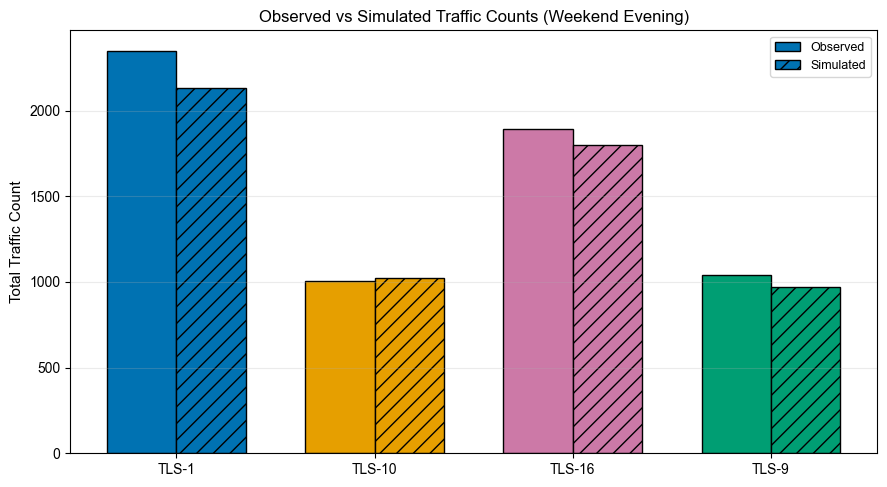

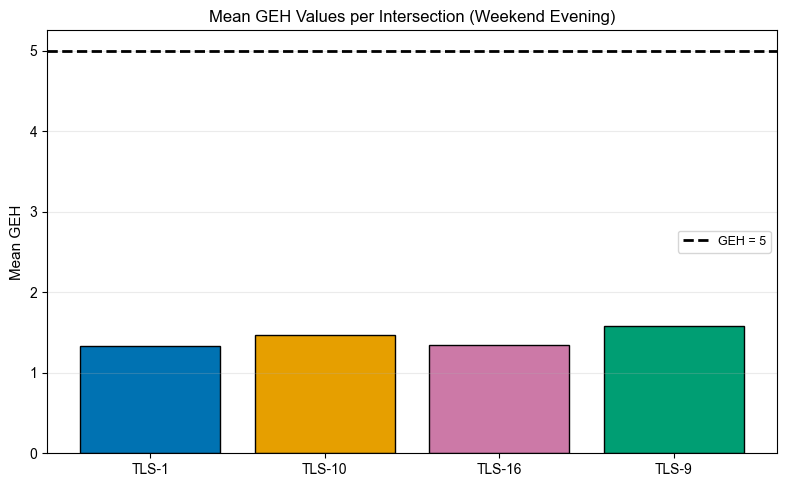

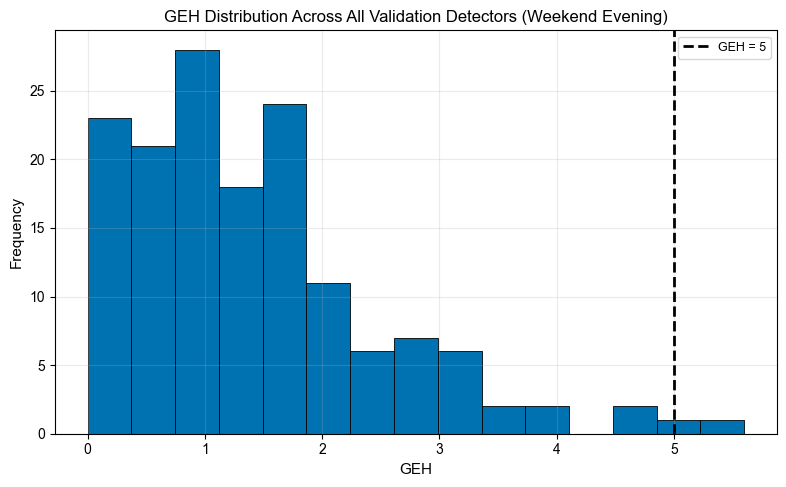

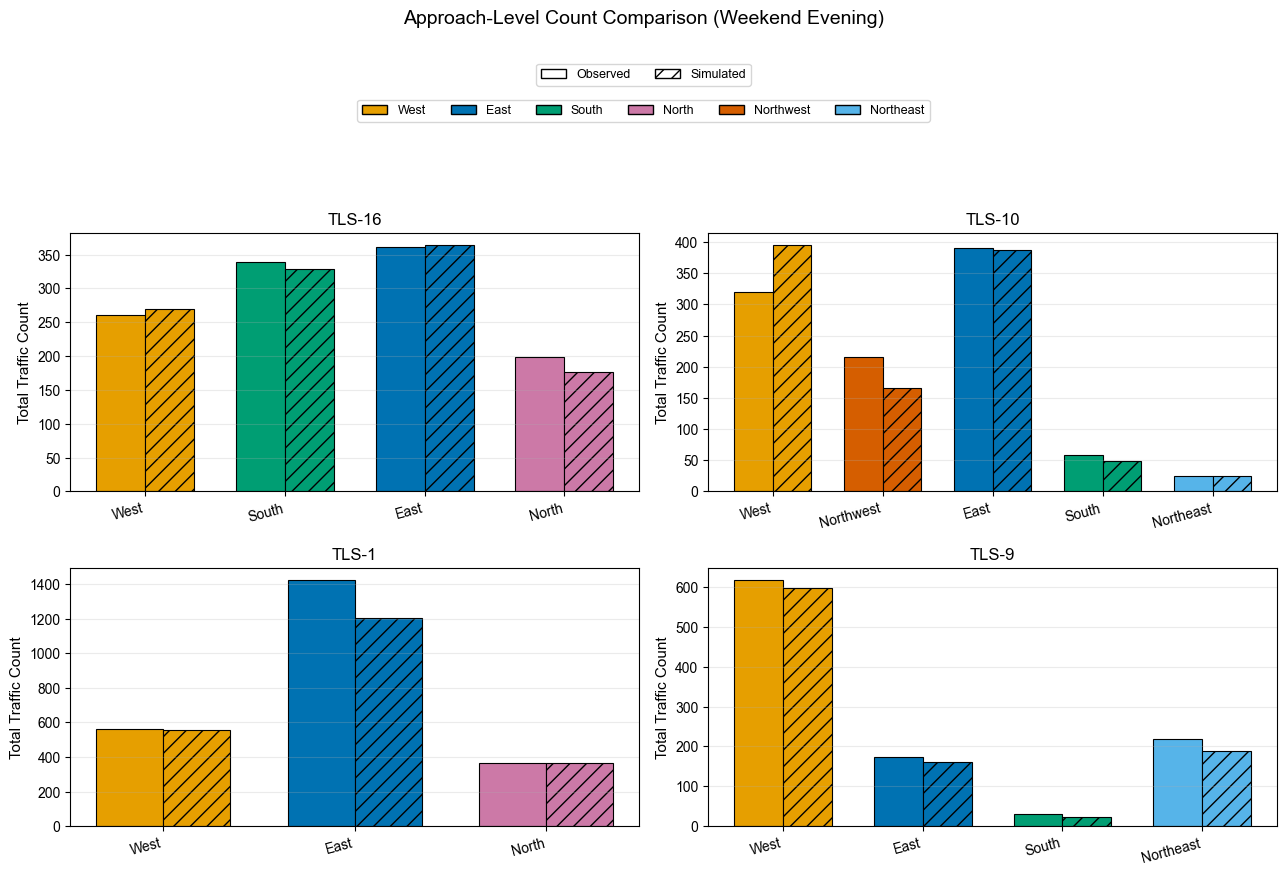

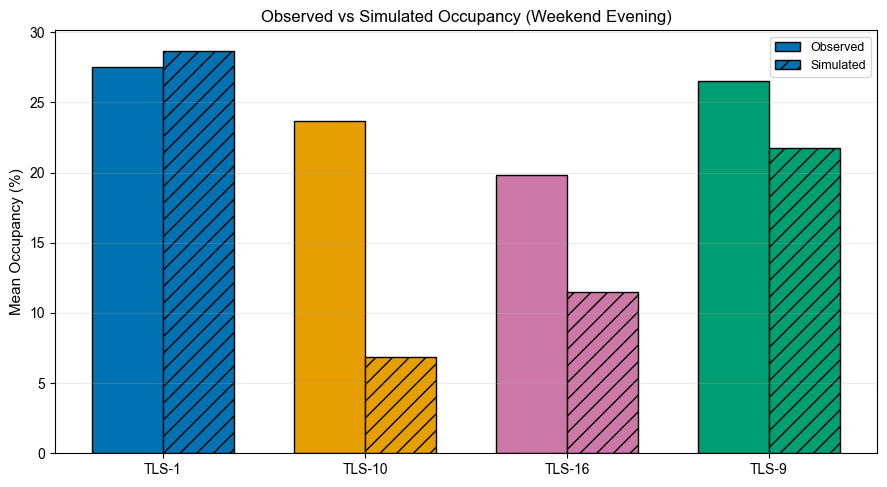

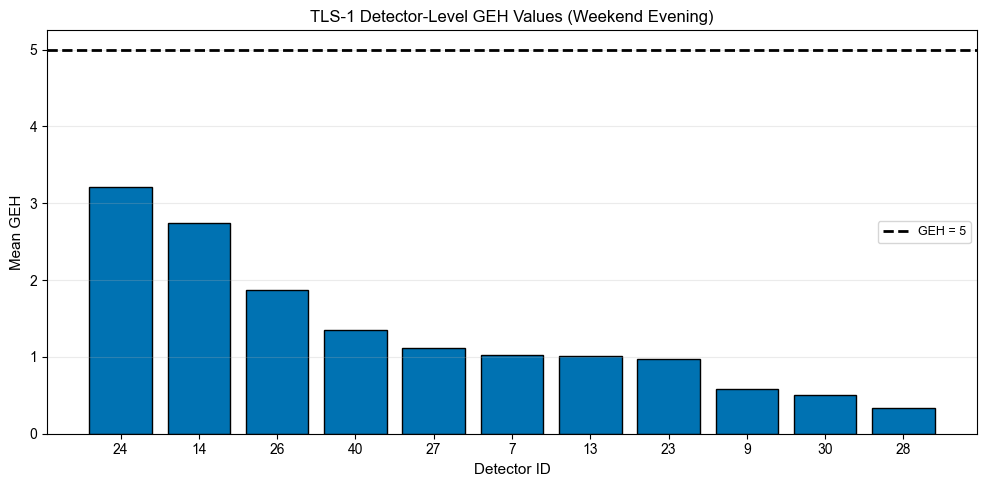

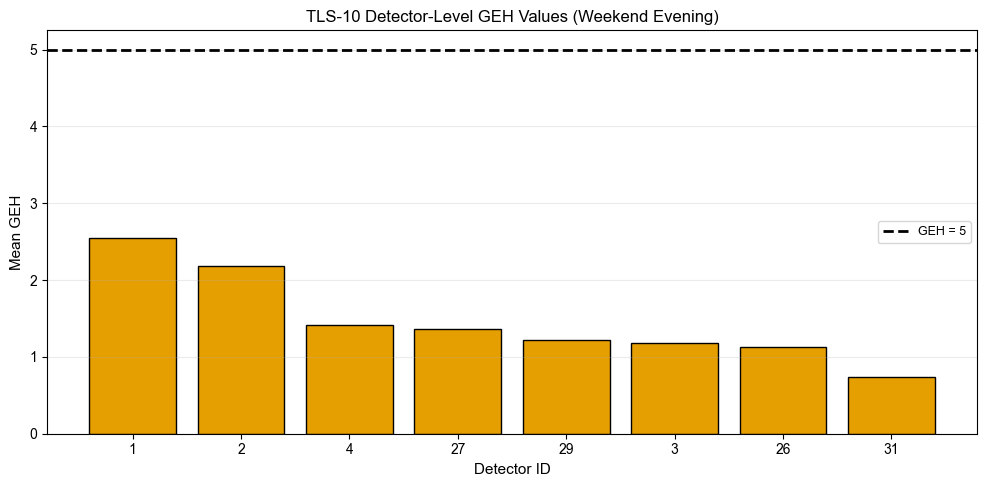

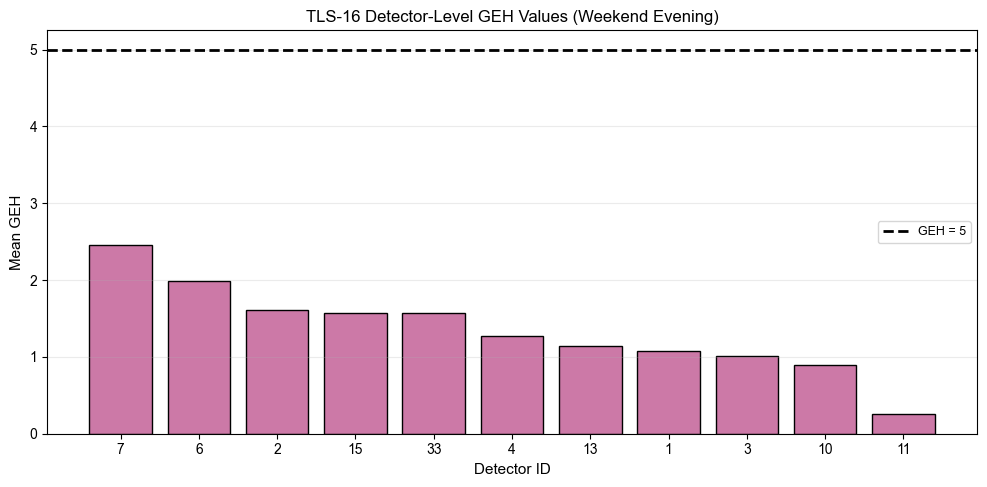

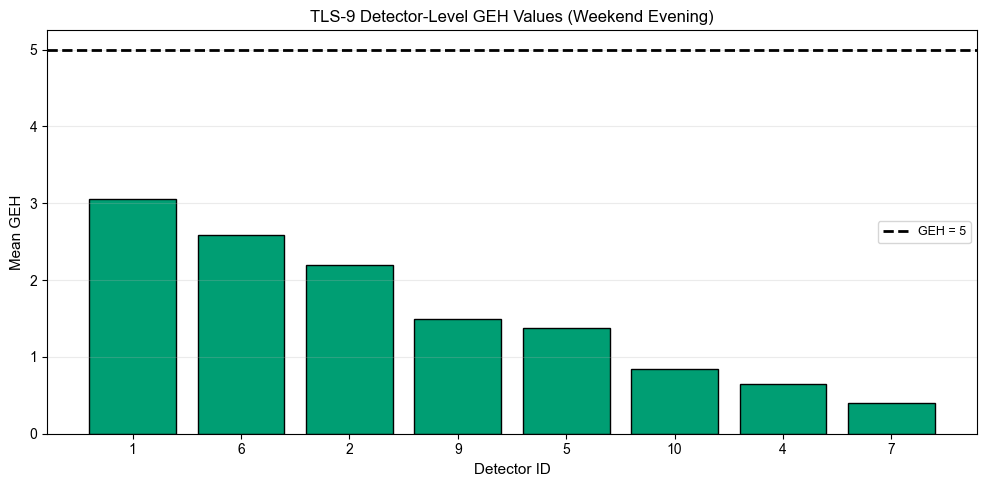

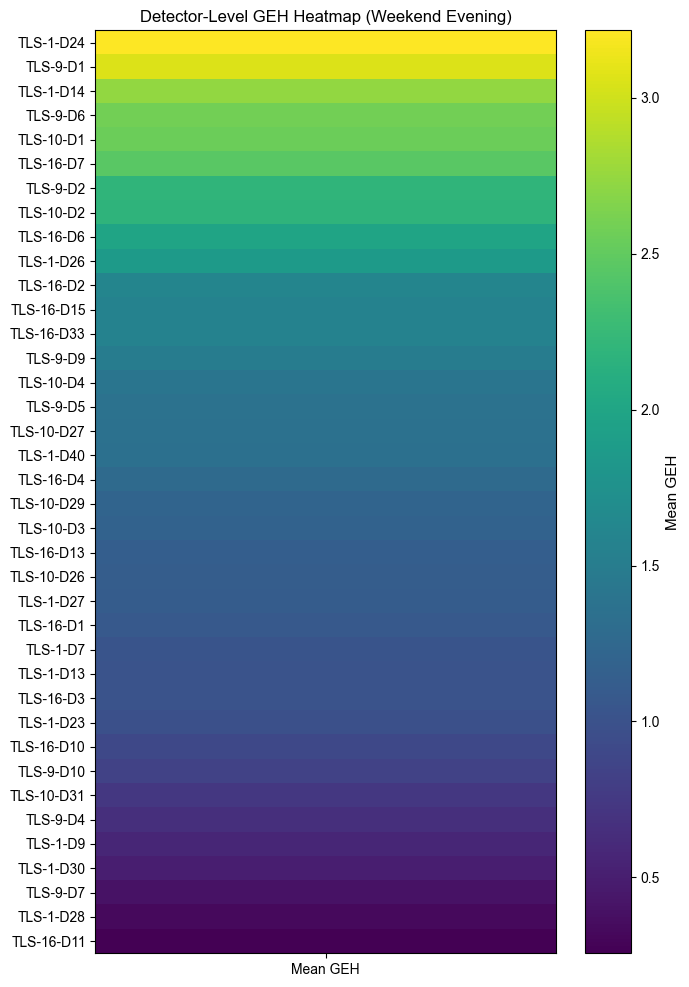


FINAL CALIBRATION SUMMARY - Weekend Evening
   TLS  total_real  total_sim  mean_GEH  max_GEH  GEH_lt_5_share_percent
 TLS-1        2350     2130.0  1.336941 4.677783                 100.000
TLS-10        1008     1022.0  1.471481 5.112926                  96.875
TLS-16        1894     1796.0  1.349324 3.810004                 100.000
 TLS-9        1043      971.0  1.575896 5.597619                  96.875

Saved figures and summary table in:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\digital_twin\thesis_complete_figures\weekend_evening


In [28]:
# ============================================================
# COMPLETE THESIS VISUALIZATION PACKAGE
# CALIBRATION + OCCUPANCY + APPENDIX + COMBINED APPROACH FIGURE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# ============================================================
# THESIS STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})

# ============================================================
# SETTINGS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre")

SCENARIO_NAME = "weekend_evening"
# options:
# "weekday_morning", "weekday_evening",
# "weekend_morning", "weekend_evening"

COUNT_DIR = BASE_DIR / r"digital_twin\validation_outputs"
OCC_DIR = BASE_DIR / r"digital_twin\validation_outputs_new"

OUT_DIR = BASE_DIR / r"digital_twin\thesis_complete_figures" / SCENARIO_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

count_df = pd.read_csv(
    COUNT_DIR / f"{SCENARIO_NAME}_comparison_15min_counts_TRUE_warmup15.csv"
)

occ_df = pd.read_csv(
    OCC_DIR / f"{SCENARIO_NAME}_comparison_15min_occupancy_warmup15.csv"
)

# ============================================================
# COLORS
# ============================================================

TLS_COLORS = {
    "LD-LSA1": "#0072B2",
    "LD-LSA10": "#E69F00",
    "LD-LSA16": "#CC79A7",
    "LD-LSA9": "#009E73",
}

TLS_LABELS = {
    "LD-LSA1": "TLS-1",
    "LD-LSA10": "TLS-10",
    "LD-LSA16": "TLS-16",
    "LD-LSA9": "TLS-9",
}

INTERSECTION_ORDER = ["LD-LSA1", "LD-LSA10", "LD-LSA16", "LD-LSA9"]

INTERSECTION_APPROACHES = {
    "LD-LSA16": {
        "West": [3, 4],
        "South": [1, 2, 33],
        "East": [10, 11],
        "North": [6, 7],
    },

    "LD-LSA10": {
        "West": [1],
        "Northwest": [2, 26, 27],
        "East": [3, 4],
        "South": [31],
        "Northeast": [29],
    },

    "LD-LSA1": {
        "West": [7, 9],
        "East": [13, 14, 23, 24, 26, 27],
        "North": [28, 30, 40],
    },

    "LD-LSA9": {
        "West": [1, 2],
        "East": [9, 8],
        "South": [10],
        "Northeast": [4, 5, 6, 7],
    },
}

APPROACH_COLORS = {
    "West": "#E69F00",
    "East": "#0072B2",
    "South": "#009E73",
    "North": "#CC79A7",
    "Northwest": "#D55E00",
    "Northeast": "#56B4E9",
}

SCENARIO_TITLE = SCENARIO_NAME.replace("_", " ").title()

# ============================================================
# FIGURE 1: OBSERVED VS SIMULATED COUNTS BY INTERSECTION
# ============================================================

summary = (
    count_df.groupby("intersection", as_index=False)
    .agg(
        real=("count_real", "sum"),
        sim=("count_sim", "sum")
    )
)

summary["intersection"] = pd.Categorical(
    summary["intersection"],
    categories=INTERSECTION_ORDER,
    ordered=True
)
summary = summary.sort_values("intersection")

summary["color"] = summary["intersection"].map(TLS_COLORS)

x = np.arange(len(summary))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    x - width / 2,
    summary["real"],
    width,
    color=summary["color"],
    edgecolor="black",
    linewidth=1,
    label="Observed"
)

ax.bar(
    x + width / 2,
    summary["sim"],
    width,
    color=summary["color"],
    edgecolor="black",
    linewidth=1,
    hatch="//",
    label="Simulated"
)

ax.set_xticks(x)
ax.set_xticklabels([TLS_LABELS[i] for i in summary["intersection"]])
ax.set_ylabel("Total Traffic Count")
ax.set_title(f"Observed vs Simulated Traffic Counts ({SCENARIO_TITLE})")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    OUT_DIR / f"{SCENARIO_NAME}_overall_count_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 2: MEAN GEH BY INTERSECTION
# ============================================================

geh_summary = (
    count_df.groupby("intersection", as_index=False)
    .agg(
        mean_GEH=("GEH", "mean"),
        max_GEH=("GEH", "max")
    )
)

geh_summary["intersection"] = pd.Categorical(
    geh_summary["intersection"],
    categories=INTERSECTION_ORDER,
    ordered=True
)
geh_summary = geh_summary.sort_values("intersection")

geh_summary["color"] = geh_summary["intersection"].map(TLS_COLORS)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    [TLS_LABELS[i] for i in geh_summary["intersection"]],
    geh_summary["mean_GEH"],
    color=geh_summary["color"],
    edgecolor="black"
)

ax.axhline(
    y=5,
    linestyle="--",
    linewidth=2,
    color="black",
    label="GEH = 5"
)

ax.set_ylabel("Mean GEH")
ax.set_title(f"Mean GEH Values per Intersection ({SCENARIO_TITLE})")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    OUT_DIR / f"{SCENARIO_NAME}_mean_GEH_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 3: GEH DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    count_df["GEH"],
    bins=15,
    color="#0072B2",
    edgecolor="black",
    linewidth=0.6
)

ax.axvline(
    x=5,
    linestyle="--",
    linewidth=2,
    color="black",
    label="GEH = 5"
)

ax.set_xlabel("GEH")
ax.set_ylabel("Frequency")
ax.set_title(f"GEH Distribution Across All Validation Detectors ({SCENARIO_TITLE})")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    OUT_DIR / f"{SCENARIO_NAME}_GEH_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 4: COMBINED APPROACH-LEVEL COUNT COMPARISON
# ============================================================

combined_order = ["LD-LSA16", "LD-LSA10", "LD-LSA1", "LD-LSA9"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, intersection_name in zip(axes, combined_order):

    approach_dict = INTERSECTION_APPROACHES[intersection_name]
    sub_df = count_df[count_df["intersection"] == intersection_name].copy()

    rows = []

    for approach_name, dets in approach_dict.items():
        temp = sub_df[sub_df["detector_id"].isin(dets)]

        rows.append({
            "approach": approach_name,
            "observed": temp["count_real"].sum(),
            "simulated": temp["count_sim"].sum(),
            "color": APPROACH_COLORS.get(approach_name, "#666666")
        })

    app_df = pd.DataFrame(rows)

    x = np.arange(len(app_df))
    width = 0.35

    ax.bar(
        x - width / 2,
        app_df["observed"],
        width,
        color=app_df["color"],
        edgecolor="black",
        linewidth=0.8
    )

    ax.bar(
        x + width / 2,
        app_df["simulated"],
        width,
        color=app_df["color"],
        edgecolor="black",
        linewidth=0.8,
        hatch="//"
    )

    ax.set_title(TLS_LABELS[intersection_name])
    ax.set_xticks(x)
    ax.set_xticklabels(app_df["approach"], rotation=15, ha="right")
    ax.set_ylabel("Total Traffic Count")
    ax.grid(axis="y", alpha=0.25)

obs_sim_handles = [
    Patch(facecolor="white", edgecolor="black", label="Observed"),
    Patch(facecolor="white", edgecolor="black", hatch="//", label="Simulated"),
]

approach_handles = [
    Patch(facecolor="#E69F00", edgecolor="black", label="West"),
    Patch(facecolor="#0072B2", edgecolor="black", label="East"),
    Patch(facecolor="#009E73", edgecolor="black", label="South"),
    Patch(facecolor="#CC79A7", edgecolor="black", label="North"),
    Patch(facecolor="#D55E00", edgecolor="black", label="Northwest"),
    Patch(facecolor="#56B4E9", edgecolor="black", label="Northeast"),
]

fig.legend(
    handles=obs_sim_handles,
    loc="upper center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 1.03)
)

fig.legend(
    handles=approach_handles,
    loc="upper center",
    ncol=6,
    frameon=True,
    bbox_to_anchor=(0.5, 0.985)
)

fig.suptitle(
    f"Approach-Level Count Comparison ({SCENARIO_TITLE})",
    fontsize=14,
    y=1.09
)

plt.tight_layout(rect=[0, 0, 1, 0.90])

plt.savefig(
    OUT_DIR / f"{SCENARIO_NAME}_combined_approach_level_count_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 5: OCCUPANCY VALIDATION
# ============================================================

occ_summary = (
    occ_df.groupby("intersection", as_index=False)
    .agg(
        occ_real=("occupancy_real", "mean"),
        occ_sim=("occupancy_sim", "mean")
    )
)

occ_summary["intersection"] = pd.Categorical(
    occ_summary["intersection"],
    categories=INTERSECTION_ORDER,
    ordered=True
)
occ_summary = occ_summary.sort_values("intersection")

occ_summary["color"] = occ_summary["intersection"].map(TLS_COLORS)

x = np.arange(len(occ_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    x - width / 2,
    occ_summary["occ_real"],
    width,
    color=occ_summary["color"],
    edgecolor="black",
    linewidth=1,
    label="Observed"
)

ax.bar(
    x + width / 2,
    occ_summary["occ_sim"],
    width,
    color=occ_summary["color"],
    edgecolor="black",
    linewidth=1,
    hatch="//",
    label="Simulated"
)

ax.set_xticks(x)
ax.set_xticklabels([TLS_LABELS[i] for i in occ_summary["intersection"]])
ax.set_ylabel("Mean Occupancy (%)")
ax.set_title(f"Observed vs Simulated Occupancy ({SCENARIO_TITLE})")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    OUT_DIR / f"{SCENARIO_NAME}_occupancy_validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 6: APPENDIX DETECTOR-BY-DETECTOR GEH
# ============================================================

for intersection_name in INTERSECTION_ORDER:

    sub = count_df[count_df["intersection"] == intersection_name].copy()

    det_geh = (
        sub.groupby("detector_id", as_index=False)
        .agg(mean_GEH=("GEH", "mean"))
        .sort_values("mean_GEH", ascending=False)
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(
        det_geh["detector_id"].astype(str),
        det_geh["mean_GEH"],
        color=TLS_COLORS[intersection_name],
        edgecolor="black"
    )

    ax.axhline(
        y=5,
        linestyle="--",
        linewidth=2,
        color="black",
        label="GEH = 5"
    )

    ax.set_xlabel("Detector ID")
    ax.set_ylabel("Mean GEH")
    ax.set_title(f"{TLS_LABELS[intersection_name]} Detector-Level GEH Values ({SCENARIO_TITLE})")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

    plt.tight_layout()

    plt.savefig(
        OUT_DIR / f"{SCENARIO_NAME}_{TLS_LABELS[intersection_name]}_detector_GEH.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# FIGURE 7: GEH HEATMAP
# ============================================================

heatmap_df = count_df.copy()
heatmap_df["TLS"] = heatmap_df["intersection"].map(TLS_LABELS)
heatmap_df["detector_label"] = heatmap_df["TLS"] + "-D" + heatmap_df["detector_id"].astype(str)

pivot = (
    heatmap_df.pivot_table(
        index="detector_label",
        values="GEH",
        aggfunc="mean"
    )
    .sort_values("GEH", ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 10))

im = ax.imshow(
    pivot[["GEH"]],
    aspect="auto"
)

ax.set_xticks([0])
ax.set_xticklabels(["Mean GEH"])

ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_title(f"Detector-Level GEH Heatmap ({SCENARIO_TITLE})")

cbar = plt.colorbar(im)
cbar.set_label("Mean GEH")

plt.tight_layout()

plt.savefig(
    OUT_DIR / f"{SCENARIO_NAME}_GEH_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# SUMMARY TABLE
# ============================================================

summary_table = (
    count_df.groupby("intersection", as_index=False)
    .agg(
        total_real=("count_real", "sum"),
        total_sim=("count_sim", "sum"),
        mean_GEH=("GEH", "mean"),
        max_GEH=("GEH", "max"),
    )
)

summary_table["GEH_lt_5_share_percent"] = (
    count_df.groupby("intersection")["GEH"]
    .apply(lambda s: (s < 5).mean() * 100)
    .values
)

summary_table["intersection"] = pd.Categorical(
    summary_table["intersection"],
    categories=INTERSECTION_ORDER,
    ordered=True
)
summary_table = summary_table.sort_values("intersection")

summary_table["TLS"] = summary_table["intersection"].map(TLS_LABELS)

summary_table = summary_table[
    [
        "TLS",
        "total_real",
        "total_sim",
        "mean_GEH",
        "max_GEH",
        "GEH_lt_5_share_percent",
    ]
]

summary_csv = OUT_DIR / f"{SCENARIO_NAME}_final_calibration_summary.csv"

summary_table.to_csv(
    summary_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\n===================================================")
print(f"FINAL CALIBRATION SUMMARY - {SCENARIO_TITLE}")
print("===================================================")
print(summary_table.to_string(index=False))

print("\nSaved figures and summary table in:")
print(OUT_DIR)